# Fast-Dev Notebook for Char-Level Next-Character Prediction (Transformer)
本 notebook 用于 **小规模、快速实验**：
- 使用数据子集（或短序列）
- 极小模型（层数/维度更小）
- 迭代步数少，评估更频繁

定好超参与架构后，再把配置迁回“全量训练”的主 notebook。

In [1]:
import math, os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# 统一随机性，便于对比
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# FAST-DEV 开关：True=小实验；False=较大规模
FAST_DEV = True

# 统一管理实验规模
if FAST_DEV:
    DATA_FRACTION = 0.05        # 用 5% 数据
    MAX_ITERS     = 1500        # 训练步数（总更新数）
    EVAL_INTERVAL = 100         # 评估频率
    BATCH_SIZE    = 32
    N_LAYERS      = 2
    N_HEADS       = 2
    D_MODEL       = 128
    D_FF          = 4 * D_MODEL
    CONTEXT_LEN   = 64          # L：上下文窗口
    LR            = 3e-4
    WARMUP_STEPS  = 200
else:
    DATA_FRACTION = 1.0
    MAX_ITERS     = 100_000
    EVAL_INTERVAL = 1000
    BATCH_SIZE    = 64
    N_LAYERS      = 6
    N_HEADS       = 8
    D_MODEL       = 512
    D_FF          = 4 * D_MODEL
    CONTEXT_LEN   = 128
    LR            = 3e-4
    WARMUP_STEPS  = 2000


Device: cpu


In [2]:
# === Load Data (small subset for Fast-Dev) ===

DATA_FRACTION = 0.05   # 用 5% 数据调参（可在上方全局调）

train_path = "./data/text8_train.txt"
test_path = "./data/text8_test.txt"

with open(train_path, "r") as f:
    train_text = f.read()
with open(test_path, "r") as f:
    test_text = f.read()

print(f"Original lengths: train={len(train_text):_}, test={len(test_text):_}")

# ↓↓↓ 新增：只取一部分做快实验 ↓↓↓
if DATA_FRACTION < 1.0:
    train_text = train_text[:int(len(train_text) * DATA_FRACTION)]
    test_text  = test_text[:int(len(test_text) * DATA_FRACTION)]
    print(f"Using subset: train={len(train_text):_}, test={len(test_text):_}")

# print a small preview
print("Sample training text preview:", repr(train_text[:200]))



Original lengths: train=90_000_000, test=5_000_000
Using subset: train=4_500_000, test=250_000
Sample training text preview: ' anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english revolution and the sans culottes of the french revolution whilst the term '


In [3]:
# === Tokenizer & Encode (基于 train_text + test_text 构建字符表) ===
import torch

# 1) 字符表
chars = sorted(list(set(train_text + test_text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)
print(f"vocab_size = {vocab_size}")
print("vocab preview:", chars[:50])

# 2) 编码/解码函数
def encode(s: str) -> torch.Tensor:
    return torch.tensor([stoi[c] for c in s], dtype=torch.long)

def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)

# 3) 文本 -> ids
train_ids = encode(train_text)
test_ids  = encode(test_text)

# 4) 从训练集再切出一个小验证集（避免用 test 做调参）
val_ratio = 0.1
split = int(len(train_ids) * (1 - val_ratio))
train_data = train_ids[:split]
val_data   = train_ids[split:]

print(f"train_data={len(train_data):_}, val_data={len(val_data):_}, test_data={len(test_ids):_}")


vocab_size = 27
vocab preview: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
train_data=4_050_000, val_data=450_000, test_data=250_000


In [4]:
def get_batch(split, batch_size=BATCH_SIZE, block_size=CONTEXT_LEN):
    data_ = train_data if split == "train" else val_data
    # 随机选择起点
    ix = torch.randint(0, len(data_) - block_size - 1, (batch_size,))
    x = torch.stack([data_[i:i+block_size] for i in ix])
    y = torch.stack([data_[i+1:i+block_size+1] for i in ix])  # 下一字符
    return x.to(device), y.to(device)


In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # 下三角 mask
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x).view(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # 形状: (B, nH, T, Hd)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v  # (B, nH, T, Hd)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, block_size, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.block_size = block_size

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device).unsqueeze(0)
        x = self.token_emb(idx) + self.pos_emb(pos)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)                     # (B, T, vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=200):
        # 使用滑动窗口 CONTEXT_LEN
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [6]:
# === 小规模超参数网格搜索配置 ===
import itertools, time, math, torch, pandas as pd

# 搜索范围（建议每次只动1~2组参数）
SEARCH = {
    "LR": [1e-3, 5e-4, 3e-4, 1e-4],           # 学习率
    "WARMUP_STEPS": [100, 300, 1000],         # warmup 步数
    "CONTEXT_LEN": [32, 64, 128],             # 上下文窗口长度 L
}

# 其它参数使用你当前 notebook 的默认值
DEFAULTS = {
    "LR": LR,
    "WARMUP_STEPS": WARMUP_STEPS,
    "BATCH_SIZE": BATCH_SIZE,
    "CONTEXT_LEN": CONTEXT_LEN,
    "N_LAYERS": N_LAYERS,
    "N_HEADS": N_HEADS,
    "D_MODEL": D_MODEL,
    "D_FF": D_FF,
}

# 搜索组合（例：LR × WARMUP × L）
grid = []
for lr in SEARCH["LR"]:
    for warm in SEARCH["WARMUP_STEPS"]:
        for L in SEARCH["CONTEXT_LEN"]:
            cfg = DEFAULTS.copy()
            cfg.update({"LR": lr, "WARMUP_STEPS": warm, "CONTEXT_LEN": L})
            grid.append(cfg)

print(f"共 {len(grid)} 组实验配置")


共 36 组实验配置


In [7]:
# === 自动小网格实验并记录结果 ===
results = []

def train_and_eval(cfg, steps=800, seed=42):
    torch.manual_seed(seed)
    model_ = TinyGPT(
        vocab_size=vocab_size, block_size=cfg["CONTEXT_LEN"],
        n_layers=cfg["N_LAYERS"], n_heads=cfg["N_HEADS"],
        d_model=cfg["D_MODEL"], d_ff=cfg["D_FF"], dropout=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(
        model_.parameters(),
        lr=cfg["LR"], betas=(0.9, 0.95), weight_decay=0.1
    )

    def lr_schedule(it):
        if it < cfg["WARMUP_STEPS"]:
            return cfg["LR"] * (it + 1) / max(1, cfg["WARMUP_STEPS"])
        progress = (it - cfg["WARMUP_STEPS"]) / max(1, steps - cfg["WARMUP_STEPS"])
        return 0.1 * cfg["LR"] + 0.9 * cfg["LR"] * 0.5 * (1 + math.cos(math.pi * progress))

    model_.train()
    t0 = time.time()
    for it in range(steps):
        for pg in optimizer.param_groups:
            pg["lr"] = lr_schedule(it)
        xb, yb = get_batch("train", batch_size=cfg["BATCH_SIZE"], block_size=cfg["CONTEXT_LEN"])
        _, loss = model_(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_.parameters(), 1.0)
        optimizer.step()
    elapsed = time.time() - t0

    # 快速验证
    @torch.no_grad()
    def val_acc_last():
        model_.eval()
        x, y = get_batch("val", batch_size=256, block_size=cfg["CONTEXT_LEN"])
        logits, _ = model_(x, y)
        preds = logits.argmax(dim=-1)
        return (preds[:, -1] == y[:, -1]).float().mean().item()

    acc = val_acc_last()
    return {"val_acc_last": acc, "time_sec": elapsed}


for i, cfg in enumerate(grid, 1):
    print(f"[{i}/{len(grid)}] Running: LR={cfg['LR']}, Warmup={cfg['WARMUP_STEPS']}, L={cfg['CONTEXT_LEN']}")
    out = train_and_eval(cfg)
    row = {**cfg, **out}
    print(f"  → acc_last={row['val_acc_last']*100:.2f}%, time={row['time_sec']:.1f}s")
    results.append(row)

df = pd.DataFrame(results).sort_values("val_acc_last", ascending=False)
from caas_jupyter_tools import display_dataframe_to_user
display_dataframe_to_user("Mini-grid results (val_acc_last)", df)

csv_path = "/mnt/data/mini_grid_results.csv"
df.to_csv(csv_path, index=False)
print("结果已保存：", csv_path)


[1/36] Running: LR=0.001, Warmup=100, L=32
  → acc_last=35.94%, time=12.6s
[2/36] Running: LR=0.001, Warmup=100, L=64
  → acc_last=33.59%, time=26.1s
[3/36] Running: LR=0.001, Warmup=100, L=128
  → acc_last=32.03%, time=75.3s
[4/36] Running: LR=0.001, Warmup=300, L=32
  → acc_last=36.33%, time=15.4s
[5/36] Running: LR=0.001, Warmup=300, L=64
  → acc_last=34.38%, time=31.7s
[6/36] Running: LR=0.001, Warmup=300, L=128
  → acc_last=31.64%, time=77.3s
[7/36] Running: LR=0.001, Warmup=1000, L=32
  → acc_last=34.38%, time=21.3s
[8/36] Running: LR=0.001, Warmup=1000, L=64
  → acc_last=35.16%, time=36.5s
[9/36] Running: LR=0.001, Warmup=1000, L=128
  → acc_last=25.00%, time=76.4s
[10/36] Running: LR=0.0005, Warmup=100, L=32
  → acc_last=32.03%, time=17.4s
[11/36] Running: LR=0.0005, Warmup=100, L=64
  → acc_last=28.52%, time=38.1s
[12/36] Running: LR=0.0005, Warmup=100, L=128
  → acc_last=26.17%, time=82.6s
[13/36] Running: LR=0.0005, Warmup=300, L=32
  → acc_last=34.77%, time=17.8s
[14/36] Ru

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [8]:
import pandas as pd

# 把刚才循环得到的 results 列表整理成表
df = pd.DataFrame(results).sort_values("val_acc_last", ascending=False)

print(df)  # 控制台直接打印所有结果，按 acc_last 从高到低排序

# 保存到当前目录下的 csv 文件
csv_path = "mini_grid_results.csv"
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)


        LR  WARMUP_STEPS  BATCH_SIZE  CONTEXT_LEN  N_LAYERS  N_HEADS  D_MODEL  \
3   0.0010           300          32           32         2        2      128   
0   0.0010           100          32           32         2        2      128   
7   0.0010          1000          32           64         2        2      128   
12  0.0005           300          32           32         2        2      128   
4   0.0010           300          32           64         2        2      128   
6   0.0010          1000          32           32         2        2      128   
1   0.0010           100          32           64         2        2      128   
2   0.0010           100          32          128         2        2      128   
9   0.0005           100          32           32         2        2      128   
5   0.0010           300          32          128         2        2      128   
15  0.0005          1000          32           32         2        2      128   
10  0.0005           100    

In [9]:
import pandas as pd

# 读取第一轮结果
df1 = pd.read_csv("mini_grid_results.csv")
df1 = df1.sort_values("val_acc_last", ascending=False).reset_index(drop=True)

print("Top-2 configs from Round 1:")
top2 = df1.head(2)
print(top2)

# 把前两名提取为 base configs（只拿会参与第二轮的关键信息）
base_configs = []
for _, row in top2.iterrows():
    base_configs.append({
        "LR": float(row["LR"]),
        "WARMUP_STEPS": int(row["WARMUP_STEPS"]),
        "CONTEXT_LEN": int(row["CONTEXT_LEN"]),
    })

print("\nBase configs for Round 2:")
for i, cfg in enumerate(base_configs, 1):
    print(f"Base {i}: {cfg}")


Top-2 configs from Round 1:
      LR  WARMUP_STEPS  BATCH_SIZE  CONTEXT_LEN  N_LAYERS  N_HEADS  D_MODEL  \
0  0.001           300          32           32         2        2      128   
1  0.001           100          32           32         2        2      128   

   D_FF  val_acc_last   time_sec  
0   512      0.363281  15.433765  
1   512      0.359375  12.599688  

Base configs for Round 2:
Base 1: {'LR': 0.001, 'WARMUP_STEPS': 300, 'CONTEXT_LEN': 32}
Base 2: {'LR': 0.001, 'WARMUP_STEPS': 100, 'CONTEXT_LEN': 32}


In [10]:
import math, time, torch
import pandas as pd

# beta2 备选：包含原版隐式默认 0.999
BETA2_CANDIDATES = [0.95, 0.98, 0.999]

STEPS2 = 600   # 每个组合跑多少步，可以按你机器情况调

second_round_results = []

def train_and_eval_round2(cfg, steps=STEPS2, seed=42):
    torch.manual_seed(seed)

    # 构建模型（沿用 smallExperiment 里的全局结构）
    model_ = TinyGPT(
        vocab_size=vocab_size,
        block_size=cfg["CONTEXT_LEN"],
        n_layers=N_LAYERS,
        n_heads=N_HEADS,
        d_model=D_MODEL,
        d_ff=D_FF,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model_.parameters(),
        lr=cfg["LR"],
        betas=(0.9, cfg["BETA2"]),   # 这里调 beta2
        weight_decay=0.0,            # 不用 weight decay
    )

    def lr_schedule(it):
        if it < cfg["WARMUP_STEPS"]:
            return cfg["LR"] * (it + 1) / max(1, cfg["WARMUP_STEPS"])
        progress = (it - cfg["WARMUP_STEPS"]) / max(1, steps - cfg["WARMUP_STEPS"])
        return 0.1 * cfg["LR"] + 0.9 * cfg["LR"] * 0.5 * (1 + math.cos(math.pi * progress))

    model_.train()
    t0 = time.time()
    for it in range(steps):
        # 更新学习率
        lr_now = lr_schedule(it)
        for pg in optimizer.param_groups:
            pg["lr"] = lr_now

        xb, yb = get_batch("train", batch_size=BATCH_SIZE, block_size=cfg["CONTEXT_LEN"])
        _, loss = model_(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_.parameters(), 1.0)
        optimizer.step()

    elapsed = time.time() - t0

    @torch.no_grad()
    def val_acc_last():
        model_.eval()
        x, y = get_batch("val", batch_size=256, block_size=cfg["CONTEXT_LEN"])
        logits, _ = model_(x, y)
        preds = logits.argmax(dim=-1)
        return (preds[:, -1] == y[:, -1]).float().mean().item()

    acc = val_acc_last()
    return {"val_acc_last": acc, "time_sec": elapsed}


# 构造第二轮搜索 grid：对每个 base config，抖 LR 和 warmup + 不同 beta2
second_grid = []

for base in base_configs:
    base_lr = base["LR"]
    base_warm = base["WARMUP_STEPS"]
    L = base["CONTEXT_LEN"]   # L 固定，不再抖

    lr_candidates = sorted(set([
        base_lr,
        base_lr * 0.7,
        base_lr * 1.3,
    ]))

    warm_candidates = sorted(set([
        base_warm,
        max(50, base_warm // 2),
        base_warm * 2,
    ]))

    for lr in lr_candidates:
        for warm in warm_candidates:
            for beta2 in BETA2_CANDIDATES:
                cfg = {
                    "LR": float(lr),
                    "WARMUP_STEPS": int(warm),
                    "CONTEXT_LEN": int(L),
                    "BETA2": float(beta2),
                    "BATCH_SIZE": BATCH_SIZE,
                }
                second_grid.append(cfg)

print(f"Round 2: total {len(second_grid)} configs to run.")


# === 实际跑第二轮搜索 ===
second_round_results = []
for i, cfg in enumerate(second_grid, 1):
    print(f"[Round 2: {i}/{len(second_grid)}] cfg={cfg}")
    out = train_and_eval_round2(cfg)
    row = {**cfg, **out}
    print(f"  -> acc_last={row['val_acc_last']*100:.2f}%, time={row['time_sec']:.1f}s")
    second_round_results.append(row)

# 汇总 & 保存
df2 = pd.DataFrame(second_round_results).sort_values("val_acc_last", ascending=False)
print("\n=== Round 2 results (sorted by val_acc_last) ===")
print(df2)

df2.to_csv("second_round_results.csv", index=False)
print("Saved second-round results to second_round_results.csv")


Round 2: total 54 configs to run.
[Round 2: 1/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 150, 'CONTEXT_LEN': 32, 'BETA2': 0.95, 'BATCH_SIZE': 32}
  -> acc_last=37.11%, time=11.9s
[Round 2: 2/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 150, 'CONTEXT_LEN': 32, 'BETA2': 0.98, 'BATCH_SIZE': 32}
  -> acc_last=37.50%, time=10.5s
[Round 2: 3/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 150, 'CONTEXT_LEN': 32, 'BETA2': 0.999, 'BATCH_SIZE': 32}
  -> acc_last=37.50%, time=11.1s
[Round 2: 4/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 300, 'CONTEXT_LEN': 32, 'BETA2': 0.95, 'BATCH_SIZE': 32}
  -> acc_last=36.72%, time=12.0s
[Round 2: 5/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 300, 'CONTEXT_LEN': 32, 'BETA2': 0.98, 'BATCH_SIZE': 32}
  -> acc_last=37.11%, time=12.4s
[Round 2: 6/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 300, 'CONTEXT_LEN': 32, 'BETA2': 0.999, 'BATCH_SIZE': 32}
  -> acc_last=37.50%, time=12.1s
[Round 2: 7/54] cfg={'LR': 0.0007, 'WARMUP_STEPS': 600, 'CONTEXT_LEN': 32, 'BETA2': 0.95, 'BATCH_SIZE': 32}
  -> acc_l

In [9]:
model = TinyGPT(
    vocab_size=vocab_size, block_size=CONTEXT_LEN,
    n_layers=N_LAYERS, n_heads=N_HEADS,
    d_model=D_MODEL, d_ff=D_FF, dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.1)

def lr_schedule(it, max_iters=MAX_ITERS, base_lr=LR, warmup=WARMUP_STEPS):
    if it < warmup:
        return base_lr * (it + 1) / warmup
    # cosine decay to 10% of base_lr
    progress = (it - warmup) / max(1, (max_iters - warmup))
    return 0.1 * base_lr + 0.9 * base_lr * 0.5 * (1 + math.cos(math.pi * progress))


In [10]:
@torch.no_grad()
def evaluate(split, num_batches=10):
    model.eval()
    losses, acc_all, acc_last = [], [], []
    for _ in range(num_batches):
        x, y = get_batch(split)
        logits, loss = model(x, y)
        losses.append(loss.item())
        # 全部位置的准确率
        pred = logits.argmax(dim=-1)
        acc_all.append((pred == y).float().mean().item())
        # 仅最后一个位置（真正 next-char）
        acc_last.append((pred[:, -1] == y[:, -1]).float().mean().item())
    model.train()
    return {
        "loss": float(np.mean(losses)),
        "acc_all": float(np.mean(acc_all)),
        "acc_last": float(np.mean(acc_last)),
    }


In [11]:
loss_history = []
val_history = []
t0 = time.time()

model.train()
for it in range(1, MAX_ITERS + 1):
    # lr 调度
    for pg in optimizer.param_groups:
        pg["lr"] = lr_schedule(it-1)

    x, y = get_batch("train")
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    loss_history.append(loss.item())

    if it % EVAL_INTERVAL == 0 or it == 1:
        train_stats = evaluate("train", num_batches=5)
        val_stats   = evaluate("val",   num_batches=5)
        elapsed = time.time() - t0
        print(f"iter {it:>6}  time {elapsed:5.1f}s | "
              f"loss(tr/val): {train_stats['loss']:.4f}/{val_stats['loss']:.4f} | "
              f"acc_all(tr/val): {train_stats['acc_all']*100:.1f}%/{val_stats['acc_all']*100:.1f}% | "
              f"acc_last(tr/val): {train_stats['acc_last']*100:.1f}%/{val_stats['acc_last']*100:.1f}%")
        val_history.append((it, val_stats["loss"], val_stats["acc_last"]))


iter      1  time   0.3s | loss(tr/val): 3.4888/3.4910 | acc_all(tr/val): 3.9%/3.8% | acc_last(tr/val): 3.1%/3.1%
iter    100  time   4.3s | loss(tr/val): 2.6699/2.6454 | acc_all(tr/val): 23.8%/24.2% | acc_last(tr/val): 32.5%/25.0%
iter    200  time   7.7s | loss(tr/val): 2.4373/2.4147 | acc_all(tr/val): 26.7%/27.7% | acc_last(tr/val): 28.1%/31.2%
iter    300  time  11.0s | loss(tr/val): 2.3924/2.3681 | acc_all(tr/val): 27.2%/27.5% | acc_last(tr/val): 31.9%/20.0%
iter    400  time  14.7s | loss(tr/val): 2.3828/2.3510 | acc_all(tr/val): 27.9%/28.2% | acc_last(tr/val): 23.8%/32.5%
iter    500  time  18.1s | loss(tr/val): 2.3467/2.3154 | acc_all(tr/val): 28.0%/30.2% | acc_last(tr/val): 29.4%/28.1%
iter    600  time  21.5s | loss(tr/val): 2.2749/2.3029 | acc_all(tr/val): 30.0%/29.0% | acc_last(tr/val): 33.1%/32.5%
iter    700  time  24.8s | loss(tr/val): 2.2654/2.2455 | acc_all(tr/val): 31.0%/31.5% | acc_last(tr/val): 33.1%/32.5%
iter    800  time  28.2s | loss(tr/val): 2.2604/2.2273 | acc

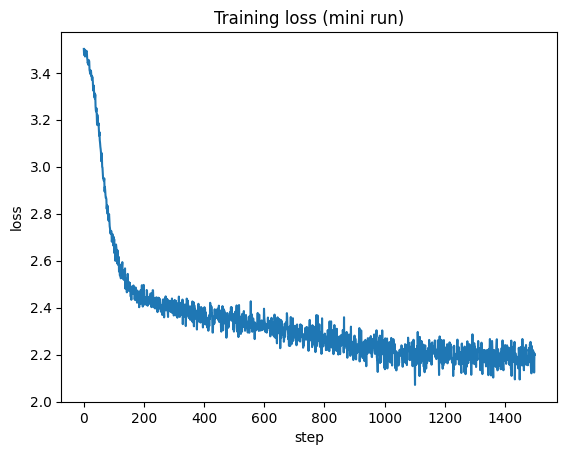

In [12]:
plt.figure()
plt.plot(loss_history)
plt.title("Training loss (mini run)")
plt.xlabel("step"); plt.ylabel("loss")
plt.show()


In [13]:
start = "hello "  # 可改成更合理的起始字符串
idx = encode(start).unsqueeze(0).to(device)
out = model.generate(idx, max_new_tokens=200)
gen = decode(out[0].tolist())
print("Generated text:\n", gen)


Generated text:
 hello woreatike the loone patm adetiee is on chimasine gue thaveage stlely seplooped the forasmic aucind one phas onicstrs the win baft ke revide nin wh shis umtes iontim ra s isalepprit hareus fak a chive 


In [ ]:
def quick_try(lr_list=(1e-3, 5e-4, 3e-4), L_list=(32, 64), steps=600):
    results = []
    for lr_ in lr_list:
        for L_ in L_list:
            torch.cuda.empty_cache() if device.type == "cuda" else None
            set_seed(42)
            model_ = TinyGPT(
                vocab_size=vocab_size, block_size=L_,
                n_layers=max(1, N_LAYERS//1), n_heads=N_HEADS, d_model=D_MODEL, d_ff=D_FF
            ).to(device)
            opt_ = torch.optim.AdamW(model_.parameters(), lr=lr_, betas=(0.9,0.95), weight_decay=0.1)
            def lr_s(it):  # 简化版调度
                if it < 100: return lr_ * (it+1)/100
                return lr_ * 0.5 * (1 + math.cos(math.pi * (it-100)/max(1, steps-100)))

            model_.train()
            for it in range(steps):
                for pg in opt_.param_groups: pg["lr"] = lr_s(it)
                x, y = get_batch("train", BATCH_SIZE, L_)
                _, loss = model_(x, y)
                opt_.zero_grad(set_to_none=True); loss.backward(); opt_.step()

            # 快速验证
            @torch.no_grad()
            def val_acc_last():
                model_.eval()
                x, y = get_batch("val", 256, L_)
                pred = model_(x)[0].argmax(dim=-1)
                return (pred[:, -1] == y[:, -1]).float().mean().item()

            acc_last = val_acc_last()
            results.append({"lr": lr_, "L": L_, "steps": steps, "acc_last": acc_last})
            print(f"[quick] lr={lr_:.1e}, L={L_}, acc_last={acc_last*100:.2f}%")

    # 简单排序与打印
    results = sorted(results, key=lambda r: r["acc_last"], reverse=True)
    print("\nTop candidates (by acc_last):")
    for r in results[:5]:
        print(r)
    return results

# 运行（可按需调整）
# quick_results = quick_try()
